# 02 — Sales Forecasting Pipeline, HistGradientBoosting + Optuna

This notebook trains a forecast-safe daily model for `Revenue` and `COGS`.

This modified version removes Ridge, LightGBM, ExtraTrees and keeps only:

1. `HistGradientBoostingRegressor`;
2. Optuna hyperparameter tuning per target;
3. `StandardScaler` applied only to numeric non-boolean columns;
4. recursive future forecasting using the best tuned HGB model per target.
5. historical seasonal priors derived only from given files;
6. lag and rolling target features generated recursively for future dates.

The primary validation metric is **MAE**.

In [9]:
%pip install scipy statsmodels plotly networkx pyvis mlxtend optuna -q


Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

from scipy.stats import f_oneway
from statsmodels.tsa.stattools import ccf
import optuna

from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")
pio.templates.default = "plotly_white"

RANDOM_STATE = 42
N_OPTUNA_TRIALS = 60

DATA_DIR = Path(".")
OUT_DIR = Path(".")
TARGETS = ["Revenue", "COGS"]

def find_file(*names):
    search_dirs = [DATA_DIR, Path("/mnt/data")]
    for base in search_dirs:
        for name in names:
            p = base / name
            if p.exists():
                return p
    raise FileNotFoundError(f"None of these files exist in {search_dirs}: {names}")

features_path = find_file("production_ready.csv")
df = pd.read_csv(features_path, parse_dates=["Date"])

# Prefer sample_submission.csv if available; otherwise infer the forecast period
# from rows where Revenue / COGS are missing.
sample_path = find_file("dataset/sample_submission.csv", "sample_submission.csv")
sample = pd.read_csv(sample_path, parse_dates=["Date"])

print(df.shape, df["Date"].min().date(), "→", df["Date"].max().date())
print(sample.shape, sample["Date"].min().date(), "→", sample["Date"].max().date())


(4381, 133) 2012-07-04 → 2024-07-01
(548, 3) 2023-01-01 → 2024-07-01


In [11]:
# Feature engineering for lags and rolling windows.
# All lags/rollings are shifted by 1 day to avoid using today's target to predict today's target.

LAGS = [1, 2, 3, 7, 14, 28, 56, 91, 182, 365, 366]
ROLL_WINDOWS = [7, 14, 28, 56, 91, 182, 365]

def add_target_history_features(data):
    data = data.sort_values("Date").copy()
    for target in TARGETS:
        for lag in LAGS:
            data[f"{target}_lag_{lag}"] = data[target].shift(lag)
        shifted = data[target].shift(1)
        for w in ROLL_WINDOWS:
            data[f"{target}_roll_mean_{w}"] = shifted.rolling(w, min_periods=max(2, w // 3)).mean()
            data[f"{target}_roll_std_{w}"] = shifted.rolling(w, min_periods=max(2, w // 3)).std()
        data[f"{target}_ewm_7"] = shifted.ewm(span=7, adjust=False, min_periods=3).mean()
        data[f"{target}_ewm_28"] = shifted.ewm(span=28, adjust=False, min_periods=7).mean()
    return data

df_feat = add_target_history_features(df)

# Do not train before lag features are sufficiently available.
train_df = df_feat[df_feat["Revenue"].notna()].copy()
train_df = train_df[train_df["Date"] >= pd.Timestamp("2013-07-04")].reset_index(drop=True)

exclude = ["Date"] + TARGETS
feature_cols = [c for c in train_df.columns if c not in exclude]
print("Train rows:", train_df.shape)
print("Feature count:", len(feature_cols))
print(feature_cols[:15])


Train rows: (3468, 187)
Feature count: 184
['month_start', 'month_end', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'seasonal_promo_active_mean', 'seasonal_promo_discount_mean', 'seasonal_sessions', 'seasonal_unique_visitors', 'seasonal_page_views', 'seasonal_bounce_rate', 'seasonal_avg_session_duration']


In [12]:
def metrics_table(y_true, y_pred, label=""):
    return {
        "label": label,
        "MAE": mean_absolute_error(y_true, y_pred),
    }

# PDF-inspired validation:
# - Primary: train through 2021, validate 2022
# - Stability: train through 2020, validate 2021
# - Horizon-like: train through mid-2021, validate next 12 months
# Additional historical folds are retained but can be downweighted mentally during model selection.
folds = [
    ("F1_old_regime", "2013-07-04", "2016-12-31", "2017-01-01", "2018-06-30"),
    ("F2_transition", "2013-07-04", "2018-12-31", "2019-01-01", "2020-06-30"),
    ("F3_stability_2021", "2013-07-04", "2020-12-31", "2021-01-01", "2021-12-31"),
    ("F4_horizon_12m", "2013-07-04", "2021-06-30", "2021-07-01", "2022-06-30"),
    ("F5_primary_2022", "2013-07-04", "2021-12-31", "2022-01-01", "2022-12-31"),
]

def make_time_weights(dates, half_life_days=730):
    max_date = dates.max()
    age = (max_date - dates).dt.days.clip(lower=0)
    return np.power(0.5, age / half_life_days)

def build_preprocessor(X_train):
    """
    StandardScaler is applied only to real numeric columns.
    Boolean columns and 0/1 indicator columns are passed through untouched.
    Other columns, if any, are ordinal-encoded safely.
    """
    bool_cols = []

    for col in X_train.columns:
        values = X_train[col].dropna().unique()
        try:
            value_set = set(values.tolist())
        except AttributeError:
            value_set = set(values)

        if len(value_set) > 0 and value_set.issubset({0, 1, True, False}):
            bool_cols.append(col)

    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in bool_cols]

    other_cols = [c for c in X_train.columns if c not in numeric_cols + bool_cols]

    transformers = []

    if numeric_cols:
        transformers.append(
            (
                "num",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            )
        )

    if bool_cols:
        transformers.append(
            (
                "bool",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                ]),
                bool_cols,
            )
        )

    if other_cols:
        transformers.append(
            (
                "other",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                ]),
                other_cols,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

def build_hist_from_params(params):
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        random_state=RANDOM_STATE,
        early_stopping=False,  # external time-series CV is safer than sklearn's random internal split
        **params,
    )

def build_hist_pipeline(params, X_train):
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor(X_train)),
        ("model", build_hist_from_params(params)),
    ])

def fit_predict_hist_pipeline(
    params,
    X_train,
    y_train,
    X_test,
    train_dates=None,
    log_target=True,
    use_weights=True,
):
    model = build_hist_pipeline(params, X_train)

    y_fit = np.log1p(y_train) if log_target else y_train
    fit_kwargs = {}

    if use_weights and train_dates is not None:
        fit_kwargs["model__sample_weight"] = make_time_weights(train_dates)

    model.fit(X_train, y_fit, **fit_kwargs)

    pred = model.predict(X_test)
    if log_target:
        pred = np.expm1(pred)

    pred = np.clip(pred, 0, None)
    return pred, model

def tune_hist_for_target(train_df, feature_cols, target, folds, n_trials=60):
    def objective(trial):
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
            "max_iter": trial.suggest_int("max_iter", 150, 1200),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 127),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 120),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-5, 10.0, log=True),
            "max_bins": trial.suggest_int("max_bins", 64, 255),
        }

        fold_maes = []

        for fold_name, tr_start, tr_end, te_start, te_end in folds:
            tr_mask = (train_df["Date"] >= tr_start) & (train_df["Date"] <= tr_end)
            te_mask = (train_df["Date"] >= te_start) & (train_df["Date"] <= te_end)

            tr = train_df.loc[tr_mask].dropna(subset=[target]).copy()
            te = train_df.loc[te_mask].dropna(subset=[target]).copy()

            if len(tr) == 0 or len(te) == 0:
                continue

            X_train = tr[feature_cols]
            y_train = tr[target]
            X_valid = te[feature_cols]
            y_valid = te[target]

            pred, _ = fit_predict_hist_pipeline(
                params=params,
                X_train=X_train,
                y_train=y_train,
                X_test=X_valid,
                train_dates=tr["Date"],
                log_target=True,
                use_weights=True,
            )

            fold_maes.append(mean_absolute_error(y_valid, pred))

        if len(fold_maes) == 0:
            return np.inf

        return float(np.mean(fold_maes))

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    return study

studies = {}
best_hist_params = {}

for target in TARGETS:
    print(f"\nTuning HistGradientBoostingRegressor for {target}...")
    studies[target] = tune_hist_for_target(
        train_df=train_df,
        feature_cols=feature_cols,
        target=target,
        folds=folds,
        n_trials=N_OPTUNA_TRIALS,
    )

    best_hist_params[target] = studies[target].best_params
    print("Best CV MAE:", studies[target].best_value)
    print("Best params:", best_hist_params[target])

# Evaluate the tuned HGB model on all folds.
cv_rows = []

for fold_name, tr_start, tr_end, te_start, te_end in folds:
    tr_mask = (train_df["Date"] >= tr_start) & (train_df["Date"] <= tr_end)
    te_mask = (train_df["Date"] >= te_start) & (train_df["Date"] <= te_end)

    tr = train_df.loc[tr_mask].dropna(subset=TARGETS).copy()
    te = train_df.loc[te_mask].dropna(subset=TARGETS).copy()

    if len(tr) == 0 or len(te) == 0:
        continue

    X_train = tr[feature_cols]
    X_valid = te[feature_cols]

    for target in TARGETS:
        y_train = tr[target]
        y_valid = te[target]

        pred, _ = fit_predict_hist_pipeline(
            params=best_hist_params[target],
            X_train=X_train,
            y_train=y_train,
            X_test=X_valid,
            train_dates=tr["Date"],
            log_target=True,
            use_weights=True,
        )

        row = metrics_table(y_valid, pred, f"{fold_name}_{target}_hgb_optuna")
        row.update({"fold": fold_name, "target": target, "model": "hgb_optuna"})
        cv_rows.append(row)

cv = pd.DataFrame(cv_rows)
display(cv.sort_values(["target", "MAE"]))
print("\nAverage by target:")
display(cv.groupby(["target", "model"])[["MAE"]].mean().sort_values(["target", "MAE"]))



Tuning HistGradientBoostingRegressor for Revenue...


[I 2026-04-27 17:48:05,089] A new study created in memory with name: no-name-57e905cc-f5ed-40f2-ada6-539e3f813608


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-04-27 17:48:55,012] Trial 0 finished with value: 651260.8981365836 and parameters: {'learning_rate': 0.02536276934555762, 'max_iter': 1149, 'max_leaf_nodes': 97, 'max_depth': 8, 'min_samples_leaf': 27, 'l2_regularization': 8.629132190071849e-05, 'max_bins': 75}. Best is trial 0 with value: 651260.8981365836.
[I 2026-04-27 17:49:03,128] Trial 1 finished with value: 674248.0014133855 and parameters: {'learning_rate': 0.08605201659336438, 'max_iter': 781, 'max_leaf_nodes': 95, 'max_depth': 3, 'min_samples_leaf': 117, 'l2_regularization': 0.9877700294007907, 'max_bins': 104}. Best is trial 0 with value: 651260.8981365836.
[I 2026-04-27 17:49:16,091] Trial 2 finished with value: 661028.4089788307 and parameters: {'learning_rate': 0.0157116608050291, 'max_iter': 342, 'max_leaf_nodes': 49, 'max_depth': 8, 'min_samples_leaf': 57, 'l2_regularization': 0.000558952420521792, 'max_bins': 181}. Best is trial 0 with value: 651260.8981365836.
[I 2026-04-27 17:49:27,968] Trial 3 finished with 

[I 2026-04-27 18:26:32,228] A new study created in memory with name: no-name-c1fcc322-6691-4815-911d-8c83cbc3aa2d


...

  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-04-27 18:27:52,006] Trial 0 finished with value: 575587.4399473555 and parameters: {'learning_rate': 0.02536276934555762, 'max_iter': 1149, 'max_leaf_nodes': 97, 'max_depth': 8, 'min_samples_leaf': 27, 'l2_regularization': 8.629132190071849e-05, 'max_bins': 75}. Best is trial 0 with value: 575587.4399473555.
[I 2026-04-27 18:28:04,128] Trial 1 finished with value: 601831.6554488557 and parameters: {'learning_rate': 0.08605201659336438, 'max_iter': 781, 'max_leaf_nodes': 95, 'max_depth': 3, 'min_samples_leaf': 117, 'l2_regularization': 0.9877700294007907, 'max_bins': 104}. Best is trial 0 with value: 575587.4399473555.
[I 2026-04-27 18:28:22,205] Trial 2 finished with value: 594666.3141596933 and parameters: {'learning_rate': 0.0157116608050291, 'max_iter': 342, 'max_leaf_nodes': 49, 'max_depth': 8, 'min_samples_leaf': 57, 'l2_regularization': 0.000558952420521792, 'max_bins': 181}. Best is trial 0 with value: 575587.4399473555.
[I 2026-04-27 18:28:38,352] Trial 3 finished with 

,label,MAE,fold,target,model
5,F3_stability_2021_COGS_hgb_optuna,470414.535431,F3_stability_2021,COGS,hgb_optuna
7,F4_horizon_12m_COGS_hgb_optuna,494651.831676,F4_horizon_12m,COGS,hgb_optuna
9,F5_primary_2022_COGS_hgb_optuna,515458.089532,F5_primary_2022,COGS,hgb_optuna
3,F2_transition_COGS_hgb_optuna,539996.234178,F2_transition,COGS,hgb_optuna
1,F1_old_regime_COGS_hgb_optuna,821227.610902,F1_old_regime,COGS,hgb_optuna
4,F3_stability_2021_Revenue_hgb_optuna,508759.830316,F3_stability_2021,Revenue,hgb_optuna
6,F4_horizon_12m_Revenue_hgb_optuna,532810.837731,F4_horizon_12m,Revenue,hgb_optuna
8,F5_primary_2022_Revenue_hgb_optuna,586139.829073,F5_primary_2022,Revenue,hgb_optuna
2,F2_transition_Revenue_hgb_optuna,586868.545665,F2_transition,Revenue,hgb_optuna
0,F1_old_regime_Revenue_hgb_optuna,950107.135931,F1_old_regime,Revenue,hgb_optuna



Average by target:


,,MAE
target,model,
COGS,hgb_optuna,568349.660344
Revenue,hgb_optuna,632937.235743


Best params: {'learning_rate': 0.025143620736083432, 'max_iter': 1009, 'max_leaf_nodes': 40, 'max_depth': 11, 'min_samples_leaf': 33, 'l2_regularization': 0.0017893778519804705, 'max_bins': 140} Best is trial 46 with value: 654119.5027003563.

Best CV MAE: 585467.7429253797
Best params: {'learning_rate': 0.05795665088868732, 'max_iter': 1199, 'max_leaf_nodes': 78, 'max_depth': 7, 'min_samples_leaf': 26, 'l2_regularization': 0.689589685226606, 'max_bins': 142}

In [13]:
# Tuned HistGradientBoosting is the only model family in this notebook.
# Each target gets its own optimized parameter set.
best_hist_params


{'Revenue': {'learning_rate': 0.05718631865447128,
  'max_iter': 807,
  'max_leaf_nodes': 15,
  'max_depth': 11,
  'min_samples_leaf': 44,
  'l2_regularization': 0.23003213524212876,
  'max_bins': 66},
 'COGS': {'learning_rate': 0.026960419845257294,
  'max_iter': 721,
  'max_leaf_nodes': 33,
  'max_depth': 11,
  'min_samples_leaf': 31,
  'l2_regularization': 0.0030759897037981212,
  'max_bins': 125}}

In [14]:
# Recursive future forecasting.
# At each future day, target lags/rollings are computed from true historical values + previous predictions.

def recursive_forecast(df_base, feature_cols, target, params, forecast_dates):
    work = df_base.sort_values("Date").copy()
    preds = []

    # Train on all available history.
    hist_feat = add_target_history_features(work)
    train_all = hist_feat[hist_feat[target].notna()].copy()
    train_all = train_all[train_all["Date"] >= pd.Timestamp("2013-07-04")]

    X_train = train_all[feature_cols]
    y_train = train_all[target]

    fitted = build_hist_pipeline(params, X_train)
    y_fit = np.log1p(y_train)
    w = make_time_weights(train_all["Date"], half_life_days=730)
    fitted.fit(X_train, y_fit, model__sample_weight=w)

    for d in forecast_dates:
        # Recompute history features after each predicted day.
        feat_work = add_target_history_features(work)
        row = feat_work.loc[feat_work["Date"] == d].copy()

        X_row = row[feature_cols]
        pred = float(np.expm1(fitted.predict(X_row)[0]))
        pred = max(pred, 0.0)

        work.loc[work["Date"] == d, target] = pred
        preds.append({"Date": d, target: pred})

    return pd.DataFrame(preds)

future_dates = sample["Date"].tolist()

pred_frames = []
for target in TARGETS:
    print("Forecasting", target, "with tuned HistGradientBoostingRegressor")
    pred_frames.append(
        recursive_forecast(
            df_base=df,
            feature_cols=feature_cols,
            target=target,
            params=best_hist_params[target],
            forecast_dates=future_dates,
        )
    )

submission = sample[["Date"]].copy()
for p in pred_frames:
    submission = submission.merge(p, on="Date", how="left")

# Business sanity constraint: preserve a minimum margin buffer.
# You can disable this if the leaderboard expects COGS > Revenue in some periods.
submission["COGS"] = np.minimum(submission["COGS"], submission["Revenue"] * 0.98)

submission_path = OUT_DIR / "submission_hgb_optuna.csv"
submission.to_csv(submission_path, index=False)

display(submission.head())
print("Saved:", submission_path)


Forecasting Revenue with tuned HistGradientBoostingRegressor
Forecasting COGS with tuned HistGradientBoostingRegressor


,Date,Revenue,COGS
0,2023-01-01,1.893241e+06,1.831175e+06
1,2023-01-02,1.765762e+06,1.657702e+06
2,2023-01-03,1.303540e+06,1.277470e+06
3,2023-01-04,1.080124e+06,1.058521e+06
4,2023-01-05,1.078061e+06,1.056500e+06


Saved: submission_hgb_optuna.csv


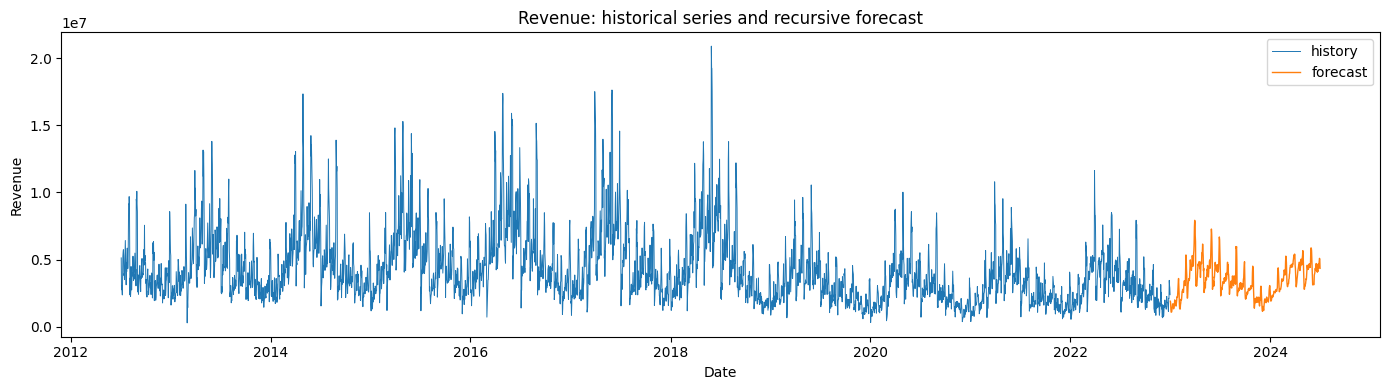

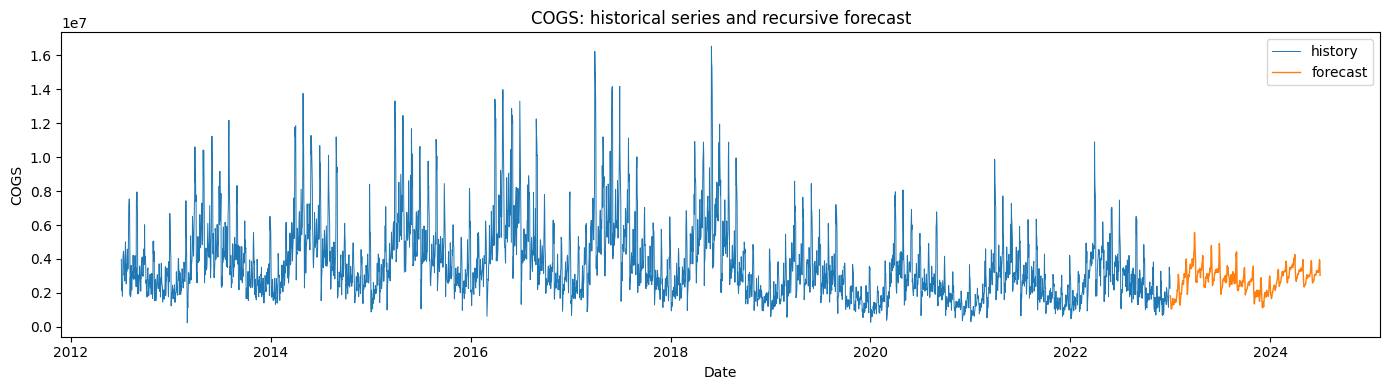

In [15]:
# Diagnostics: plot historical + forecast
import matplotlib.pyplot as plt

hist = df[df["Revenue"].notna()][["Date", "Revenue", "COGS"]]
plot_df = pd.concat([hist.assign(part="history"), submission.assign(part="forecast")], ignore_index=True)

for target in TARGETS:
    plt.figure(figsize=(14, 4))
    h = plot_df[plot_df["part"] == "history"]
    f = plot_df[plot_df["part"] == "forecast"]
    plt.plot(h["Date"], h[target], linewidth=0.7, label="history")
    plt.plot(f["Date"], f[target], linewidth=1.0, label="forecast")
    plt.title(f"{target}: historical series and recursive forecast")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [16]:
# HistGradientBoostingRegressor does not expose simple feature_importances_.
# Use permutation_importance if you want model-agnostic importance later.
print("Best HistGradientBoosting params:")
for target, params in best_hist_params.items():
    print("\n", target)
    print(params)


Best HistGradientBoosting params:

 Revenue
{'learning_rate': 0.05718631865447128, 'max_iter': 807, 'max_leaf_nodes': 15, 'max_depth': 11, 'min_samples_leaf': 44, 'l2_regularization': 0.23003213524212876, 'max_bins': 66}

 COGS
{'learning_rate': 0.026960419845257294, 'max_iter': 721, 'max_leaf_nodes': 33, 'max_depth': 11, 'min_samples_leaf': 31, 'l2_regularization': 0.0030759897037981212, 'max_bins': 125}


## Notes from the PDF and next experiments

1. The PDF argues that the 18-month horizon is too long for raw lag features alone. Recursive lag features can accumulate error, so this notebook keeps the recursive approach but you should compare it against a calendar-only version.
2. The PDF emphasizes stable annual seasonality, Tet timing, end-of-month spikes, start-of-month spikes, odd-year effects, and Q3 margin instability. If your MAE stays above 600K, the next highest-value change is to rebuild the feature matrix with explicit Tet, Fourier, end-of-month, promo-window, and odd-year features.
3. The PDF suggests recent-regime validation: 2022 as the primary fold, 2021 as stability, and a 12-month rolling horizon fold. This notebook updates the CV folds in that direction.
4. The PDF suggests calibration after model prediction. If predictions are consistently too low or too high, tune a simple multiplicative calibration factor on validation folds.
5. The PDF also suggests Q-specialist models. Even if you keep only HGB, you can train one tuned HGB per quarter with quarter-specific sample weights, then select the matching specialist at prediction time.
